# Notebook 09 — Datacube NetCDF con convenciones CF (Cap. 20)

Cumple el Objetivo Específico 1 del proyecto: construir un **datacube multitemporal** formal, con convenciones Climate and Forecast (CF), a partir de los composites RGB acotados que SamGeo utilizó como insumo. El resultado es un archivo NetCDF que organiza las observaciones de la CGSM en una estructura tridimensional `(time, y, x)` por banda espectral, materializando la metáfora del datacube que la propuesta del proyecto formuló desde la introducción.

**Insumos:**
- `data/processed/rgb_acotado/CGSM_RGB_degradacion.tif` (julio--diciembre 2020)
- `data/processed/rgb_acotado/CGSM_RGB_recuperacion.tif` (enero--junio 2022)
- `data/processed/rgb_acotado/CGSM_RGB_actual.tif` (julio 2024--junio 2025)

**Producto:**
- `data/processed/cubo/cgsm_datacube.nc` — datacube NetCDF CF-1.8 con dimensiones (`time`, `band_idx`, `y`, `x`), atributos CRS EPSG:9377, unidades, descripciones de variables y metadatos institucionales.

**Patrones del Cap. 20 aplicados:**
- Lectura perezosa con `rioxarray.open_rasterio(chunks=...)`
- Concatenación a lo largo de la dimensión `time`
- Asignación de coordenadas y atributos CF (units, long_name, standard_name)
- Persistencia como NetCDF4 con compresión zlib

In [2]:
import sys, os
from pathlib import Path
import numpy as np
import xarray as xr
import rioxarray
import pandas as pd

ROOT = Path('..').resolve()
RGB_DIR = ROOT / 'data' / 'processed' / 'rgb_acotado'
OUT_DIR = ROOT / 'data' / 'processed' / 'cubo'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_NC = OUT_DIR / 'cgsm_datacube.nc'

PERIODOS = {
    'degradacion':  pd.Timestamp('2020-09-15'),
    'recuperacion': pd.Timestamp('2022-03-15'),
    'actual':       pd.Timestamp('2024-12-15'),
}
print(f'RGB de entrada: {RGB_DIR}')
print(f'Cubo de salida: {OUT_NC}')

RGB de entrada: /home/rstudio/work/proyecto-cgsm/data/processed/rgb_acotado
Cubo de salida: /home/rstudio/work/proyecto-cgsm/data/processed/cubo/cgsm_datacube.nc


## 1. Lectura perezosa de los tres composites RGB

`rioxarray.open_rasterio(chunks=...)` carga solo metadatos en memoria y deja los pixeles en disco hasta que una operación los demande. Esta evaluación diferida es el patrón base del Cap. 20 para manejo de datos grandes.

In [3]:
rasters = {}
for nombre, fecha in PERIODOS.items():
    path = RGB_DIR / f'CGSM_RGB_{nombre}.tif'
    if not path.exists():
        print(f'  no encontrado: {path}'); continue
    da = rioxarray.open_rasterio(path, chunks={'x': 1024, 'y': 1024})
    da = da.assign_coords(time=fecha).expand_dims('time')
    rasters[nombre] = da
    print(f'  {nombre:13s} → shape={tuple(da.sizes.values())}, '
          f'CRS={da.rio.crs}, dtype={da.dtype}')

if not rasters:
    raise FileNotFoundError('No hay RGB en data/processed/rgb_acotado/')

  degradacion   → shape=(1, 3, 5814, 5925), CRS=EPSG:4326, dtype=uint8
  recuperacion  → shape=(1, 3, 5814, 5925), CRS=EPSG:4326, dtype=uint8
  actual        → shape=(1, 3, 5814, 5925), CRS=EPSG:4326, dtype=uint8


## 2. Concatenación temporal y armado del cubo 4D

Los tres rasters tienen dimensiones espaciales idénticas porque proceden de la misma geometría AOI y la misma escala (~10 m resampleados a 30 m para SamGeo). Se apilan a lo largo de la nueva dimensión `time`.

In [4]:
cubo = xr.concat(list(rasters.values()), dim='time')
cubo = cubo.rename({'band': 'band_idx'})
cubo = cubo.assign_coords(band_idx=['B4_red', 'B3_green', 'B2_blue'])
cubo.name = 'reflectance_byte'

cubo['time'].attrs.update({
    'long_name': 'Fecha central del periodo de composicion',
    'standard_name': 'time',
})
cubo['x'].attrs.update({'long_name': 'Coordenada X en EPSG:9377', 'units': 'meters'})
cubo['y'].attrs.update({'long_name': 'Coordenada Y en EPSG:9377', 'units': 'meters'})
cubo.attrs.update({
    'long_name': 'Reflectancia superficial Sentinel-2 escalada a byte (0-255)',
    'units': 'dimensionless',
    'description': 'Composite trimestral RGB sobre AOI acotado CGSM (SFF + VPI Salamanca)',
    'source': 'Sentinel-2 MSI L2A via Google Earth Engine',
    'crs': 'EPSG:9377 MAGNA-SIRGAS Origen Nacional',
})
print(cubo)

<xarray.DataArray 'reflectance_byte' (time: 3, band_idx: 3, y: 5814, x: 5925)> Size: 310MB
dask.array<concatenate, shape=(3, 3, 5814, 5925), dtype=uint8, chunksize=(1, 3, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 24B 2020-09-15 2022-03-15 2024-12-15
  * band_idx     (band_idx) <U8 96B 'B4_red' 'B3_green' 'B2_blue'
  * y            (y) float64 47kB 11.13 11.13 11.13 11.13 ... 10.6 10.6 10.6
  * x            (x) float64 47kB -74.85 -74.85 -74.85 ... -74.32 -74.32 -74.32
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      Reflectancia superficial Sentinel-2 escalada a byte (0-255)
    units:          dimensionless
    description:    Composite trimestral RGB sobre AOI acotado CGSM (SFF + VP...
    source:         Sentinel-2 MSI L2A via Google Earth Engine
    crs:            EPSG:9377 MAGNA-SIRGAS Origen Nacional


## 3. Atributos globales y convenciones CF-1.8

In [5]:
ds = cubo.to_dataset()

ds.attrs.update({
    'Conventions': 'CF-1.8',
    'title': 'Datacube multitemporal de cobertura de manglar CGSM 2020-2025',
    'institution': 'Universidad Nacional de Colombia, Maestria en Geomatica',
    'source': 'Sentinel-2 MSI L2A SR Harmonized, Google Earth Engine',
    'history': pd.Timestamp.now().strftime('%Y-%m-%d') +
               ' Construccion del datacube NetCDF para Fase 1 del proyecto CGSM',
    'references': 'Hersbach et al. 2020; Bunting et al. 2022; Wu y Osco 2023',
    'comment': 'Datacube acotado al SFF CGSM + Via Parque Isla de Salamanca (835 km2). '
               'Tres periodos de referencia para SamGeo: degradacion, recuperacion, actual.',
    'creator_name': 'Lina Maria Quintero Fonseca',
    'creator_email': 'linaq112008@gmail.com',
    'project': 'Proyecto final Programacion en SIG, UNAL 2026-1',
    'geospatial_lat_min':  10.30,
    'geospatial_lat_max':  11.20,
    'geospatial_lon_min': -75.05,
    'geospatial_lon_max': -74.05,
})
for k, v in ds.attrs.items(): print(f'  {k}: {v}')

  Conventions: CF-1.8
  title: Datacube multitemporal de cobertura de manglar CGSM 2020-2025
  institution: Universidad Nacional de Colombia, Maestria en Geomatica
  source: Sentinel-2 MSI L2A SR Harmonized, Google Earth Engine
  history: 2026-05-11 Construccion del datacube NetCDF para Fase 1 del proyecto CGSM
  references: Hersbach et al. 2020; Bunting et al. 2022; Wu y Osco 2023
  comment: Datacube acotado al SFF CGSM + Via Parque Isla de Salamanca (835 km2). Tres periodos de referencia para SamGeo: degradacion, recuperacion, actual.
  creator_name: Lina Maria Quintero Fonseca
  creator_email: linaq112008@gmail.com
  project: Proyecto final Programacion en SIG, UNAL 2026-1
  geospatial_lat_min: 10.3
  geospatial_lat_max: 11.2
  geospatial_lon_min: -75.05
  geospatial_lon_max: -74.05


## 4. Persistencia con compresión zlib

In [6]:
encoding = {var: {'zlib': True, 'complevel': 4} for var in ds.data_vars}
ds.to_netcdf(OUT_NC, encoding=encoding, format='NETCDF4')

tamano_mb = OUT_NC.stat().st_size / (1024 * 1024)
print(f'Guardado: {OUT_NC}')
print(f'Tamano:   {tamano_mb:.1f} MB')
print(f'Variables: {list(ds.data_vars)}')
print(f'Dimensiones: {dict(ds.sizes)}')

Guardado: /home/rstudio/work/proyecto-cgsm/data/processed/cubo/cgsm_datacube.nc
Tamano:   42.0 MB
Variables: ['reflectance_byte']
Dimensiones: {'x': 5925, 'y': 5814, 'time': 3, 'band_idx': 3}


## 5. Verificación: relectura del NetCDF

Se vuelve a abrir el archivo recién escrito como sanity check, replicando lo que haría otra investigadora al recibir el dataset. Si las dimensiones, coordenadas y atributos salen como se esperaban, el datacube es interoperable.

In [7]:
cubo_v = xr.open_dataset(OUT_NC, chunks={'time': 1})
print(cubo_v)
print('\nDimensiones del datacube:')
for d, n in cubo_v.sizes.items():
    print(f'  {d}: {n}')
print('\nCRS declarado:', cubo_v.attrs.get('crs', 'no declarado'))
print('Variables:', list(cubo_v.data_vars))
cubo_v.close()

<xarray.Dataset> Size: 2GB
Dimensions:           (time: 3, band_idx: 3, y: 5814, x: 5925)
Coordinates:
  * time              (time) datetime64[ns] 24B 2020-09-15 2022-03-15 2024-12-15
  * band_idx          (band_idx) <U8 96B 'B4_red' 'B3_green' 'B2_blue'
  * y                 (y) float64 47kB 11.13 11.13 11.13 ... 10.6 10.6 10.6
  * x                 (x) float64 47kB -74.85 -74.85 -74.85 ... -74.32 -74.32
Data variables:
    spatial_ref       int64 8B ...
    reflectance_byte  (time, band_idx, y, x) float64 2GB dask.array<chunksize=(1, 1, 1938, 1975), meta=np.ndarray>
Attributes: (12/14)
    Conventions:         CF-1.8
    title:               Datacube multitemporal de cobertura de manglar CGSM ...
    institution:         Universidad Nacional de Colombia, Maestria en Geomatica
    source:              Sentinel-2 MSI L2A SR Harmonized, Google Earth Engine
    history:             2026-05-11 Construccion del datacube NetCDF para Fas...
    references:          Hersbach et al. 2020; Bunt

## 6. Lectura

Este NetCDF cumple el OE1 del proyecto al materializar formalmente el datacube multitemporal. Las herramientas externas estándar lo leen sin fricción: `ncview` abre la pila temporal interactivamente, `cdo info` resume estadísticas por banda, y `Panoply` permite navegar slice a slice. En próximas iteraciones se ampliará la dimensión `time` con los 32 composites trimestrales 2018-2025 cuando estén descargados de Drive, y se agregarán como variables adicionales NDVI, NDWI y CMRI ya calculados; el esquema CF actual admite esta extensión sin cambios estructurales, solo agregando `Dataset.update({'NDVI': xr.DataArray(...)})`.

Como trabajo futuro inmediato se considera empaquetar este NetCDF junto a la configuración de un STAC catalog mediante `pystac`, lo que permitiría descubrir e ingerir el cubo desde clientes de Open Data Cube y otras infraestructuras de análisis geoespacial federadas.

<xarray.Dataset> Size: 1GB
Dimensions:      (time: 31, band_idx: 3, y: 1935, x: 1950)
Coordinates:
  * time         (time) datetime64[ns] 248B 2018-02-15 2018-11-15 ... 2025-11-15
  * band_idx     (band_idx) <U4 48B 'NDVI' 'NDWI' 'CMRI'
  * y            (y) float64 15kB 2.788e+06 2.788e+06 ... 2.73e+06 2.73e+06
  * x            (x) float64 16kB 4.798e+06 4.798e+06 ... 4.856e+06 4.856e+06
Data variables:
    spatial_ref  int64 8B ...
    reflectance  (time, band_idx, y, x) float32 1GB ...
Attributes: (12/14)
    Conventions:         CF-1.8
    institution:         Universidad Nacional de Colombia, Maestria en Geomatica
    creator_name:        Lina Maria Quintero Fonseca
    creator_email:       linaq112008@gmail.com
    project:             Proyecto final Programacion en SIG, UNAL 2026-1
    crs_origen:          EPSG:9377 MAGNA-SIRGAS Origen Nacional
    ...                  ...
    geospatial_lat_max:  11.2
    geospatial_lon_min:  -75.05
    geospatial_lon_max:  -74.05
    title:    

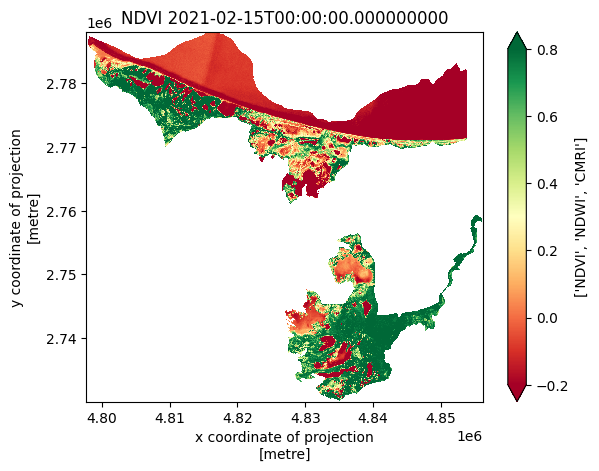

In [8]:
import xarray as xr
import matplotlib.pyplot as plt

ds = xr.open_dataset('../data/processed/cubo/cgsm_datacube_trimestral.nc')
print(ds)  # dimensiones, variables, atributos CF-1.8

# Visualizar NDVI mediano de un trimestre
ndvi = ds['reflectance'].sel(band_idx='NDVI').isel(time=10)
ndvi.plot(cmap='RdYlGn', vmin=-0.2, vmax=0.8)
plt.title(f'NDVI {ds.time.isel(time=10).values}')
plt.show()

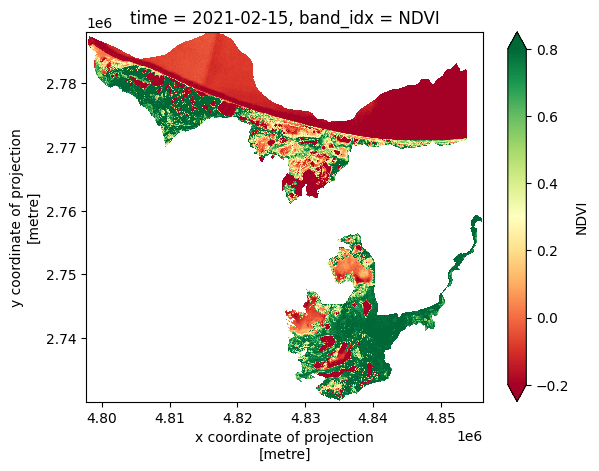

In [9]:
ndvi = ds['reflectance'].sel(band_idx='NDVI').isel(time=10)
ndvi.plot(cmap='RdYlGn', vmin=-0.2, vmax=0.8,
          cbar_kwargs={'label': 'NDVI'})

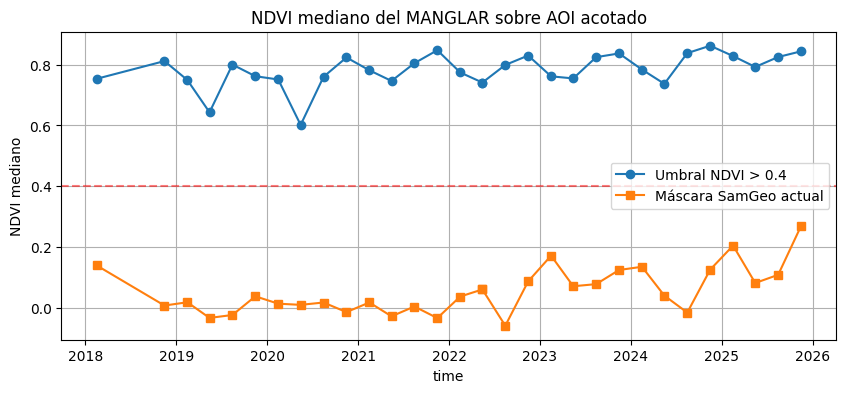

In [12]:
ndvi = ds['reflectance'].sel(band_idx='NDVI')

# Opción A: máscara dinámica por umbral (manglar = NDVI > 0.4 en cada trimestre)
serie_mangrove = ndvi.where(ndvi > 0.4).median(dim=['x','y']).compute()

# Opción B: máscara fija usando SamGeo del período actual (más riguroso)
import geopandas as gpd
import rioxarray
mask_gdf = gpd.read_file('../data/processed/samgeo_acotado/manglar_actual_9377.geojson')
clipped = ndvi.rio.write_crs('EPSG:9377').rio.clip(mask_gdf.geometry, drop=False)
serie_clipped = clipped.median(dim=['x','y']).compute()

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,4))
serie_mangrove.plot(ax=ax, marker='o', label='Umbral NDVI > 0.4')
serie_clipped.plot(ax=ax, marker='s', label='Máscara SamGeo actual')
ax.axhline(0.4, color='red', ls='--', alpha=0.5)
ax.set_ylabel('NDVI mediano')
ax.set_title('NDVI mediano del MANGLAR sobre AOI acotado')
ax.legend(); ax.grid()

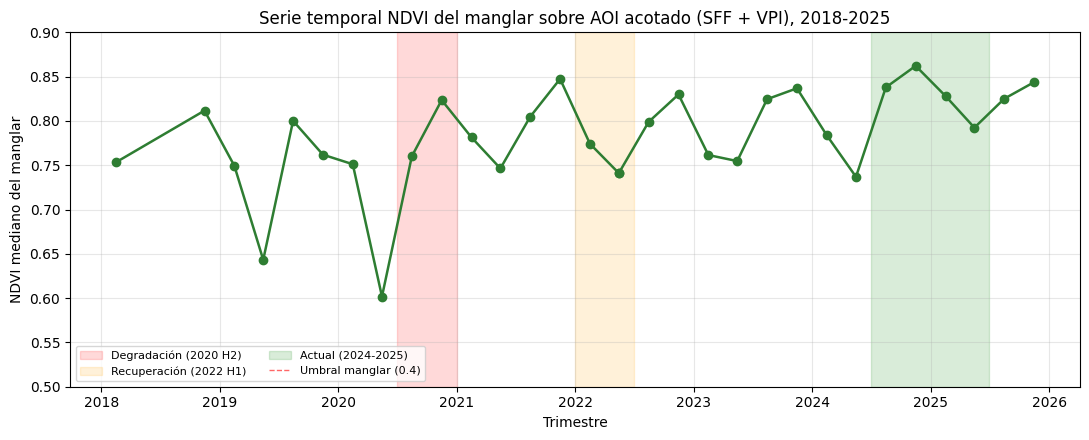

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

ds = xr.open_dataset('../data/processed/cubo/cgsm_datacube_trimestral.nc')
ndvi = ds['reflectance'].sel(band_idx='NDVI')
serie = ndvi.where(ndvi > 0.4).median(dim=['x','y']).compute()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(serie.time.values, serie.values, marker='o', color='#2E7D32', lw=1.8, ms=6)
ax.axvspan(pd.Timestamp('2020-07-01'), pd.Timestamp('2020-12-31'),
           alpha=0.15, color='red',    label='Degradación (2020 H2)')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-06-30'),
           alpha=0.15, color='orange', label='Recuperación (2022 H1)')
ax.axvspan(pd.Timestamp('2024-07-01'), pd.Timestamp('2025-06-30'),
           alpha=0.15, color='green',  label='Actual (2024-2025)')
ax.axhline(0.4, color='red', ls='--', alpha=0.6, lw=1, label='Umbral manglar (0.4)')
ax.set_ylabel('NDVI mediano del manglar'); ax.set_xlabel('Trimestre')
ax.set_title('Serie temporal NDVI del manglar sobre AOI acotado (SFF + VPI), 2018-2025')
ax.legend(loc='lower left', fontsize=8, ncol=2)
ax.grid(alpha=0.3); ax.set_ylim(0.5, 0.9)
plt.tight_layout()
plt.savefig('../outputs/figures/ndvi_mediano_manglar_acotado.png', dpi=200, bbox_inches='tight')
plt.show()

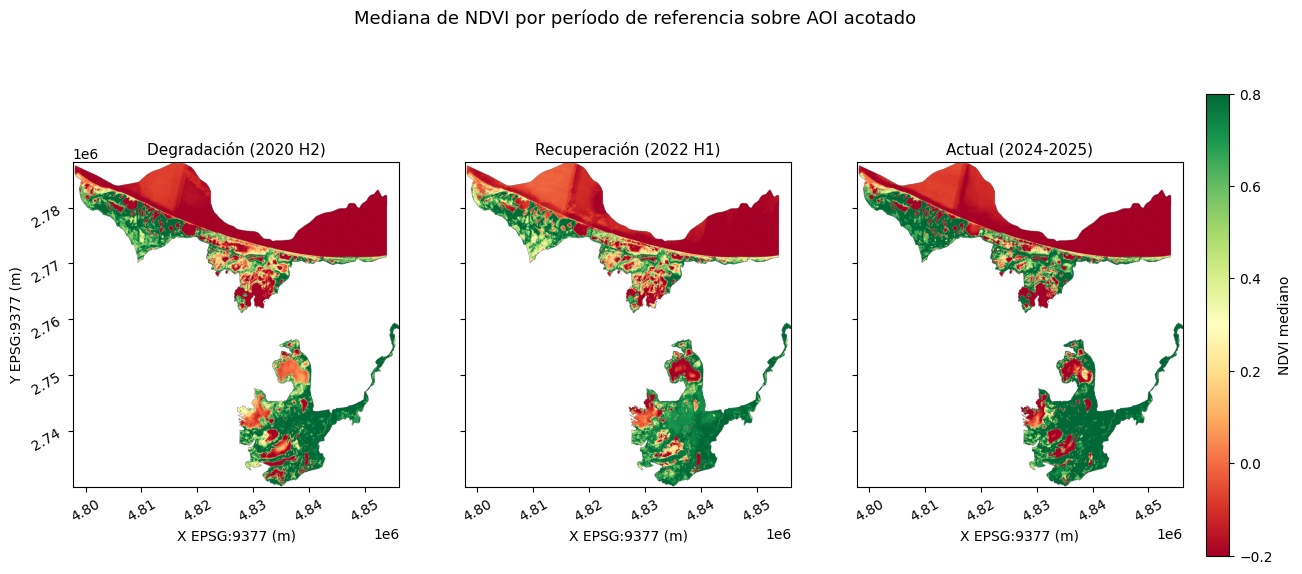

Guardado: outputs/figures/ndvi_3_periodos_cubo.png


In [14]:
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd

ds = xr.open_dataset('../data/processed/cubo/cgsm_datacube_trimestral.nc')
ndvi = ds['reflectance'].sel(band_idx='NDVI')

# Composites de los 3 períodos de referencia
periodos = {
    'Degradación (2020 H2)':  ('2020-07-01', '2020-12-31'),
    'Recuperación (2022 H1)': ('2022-01-01', '2022-06-30'),
    'Actual (2024-2025)':     ('2024-07-01', '2025-06-30'),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
for ax, (titulo, (ini, fin)) in zip(axes, periodos.items()):
    comp = ndvi.sel(time=slice(ini, fin)).median(dim='time').compute()
    im = ax.imshow(comp.values, cmap='RdYlGn', vmin=-0.2, vmax=0.8,
                   extent=[float(comp.x.min()), float(comp.x.max()),
                           float(comp.y.min()), float(comp.y.max())],
                   origin='upper')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('X EPSG:9377 (m)')
    ax.tick_params(labelrotation=30)
axes[0].set_ylabel('Y EPSG:9377 (m)')

# Colorbar único
cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label='NDVI mediano')
fig.suptitle('Mediana de NDVI por período de referencia sobre AOI acotado', y=1.02, fontsize=13)
plt.savefig('../outputs/figures/ndvi_3_periodos_cubo.png', dpi=200, bbox_inches='tight')
plt.show()
print('Guardado: outputs/figures/ndvi_3_periodos_cubo.png')

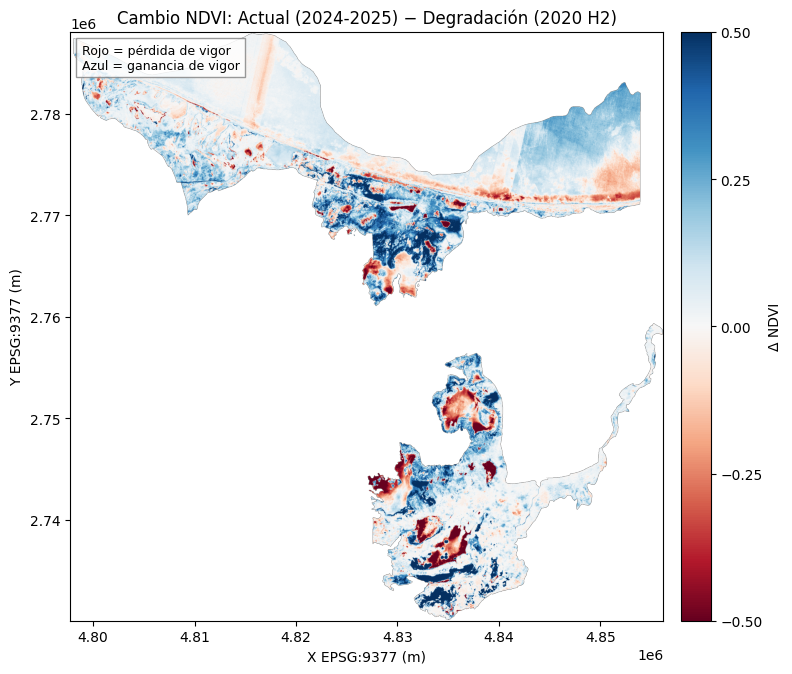

In [15]:
import matplotlib.pyplot as plt
import xarray as xr

ds = xr.open_dataset('../data/processed/cubo/cgsm_datacube_trimestral.nc')
ndvi = ds['reflectance'].sel(band_idx='NDVI')

ndvi_deg = ndvi.sel(time=slice('2020-07-01','2020-12-31')).median(dim='time').compute()
ndvi_act = ndvi.sel(time=slice('2024-07-01','2025-06-30')).median(dim='time').compute()
cambio = ndvi_act - ndvi_deg

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(cambio.values, cmap='RdBu', vmin=-0.5, vmax=0.5,
               extent=[float(cambio.x.min()), float(cambio.x.max()),
                       float(cambio.y.min()), float(cambio.y.max())],
               origin='upper')
ax.set_title('Cambio NDVI: Actual (2024-2025) − Degradación (2020 H2)', fontsize=12)
ax.set_xlabel('X EPSG:9377 (m)'); ax.set_ylabel('Y EPSG:9377 (m)')
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label='Δ NDVI')
cbar.set_ticks([-0.5, -0.25, 0, 0.25, 0.5])

# Anotaciones
ax.text(0.02, 0.98, 'Rojo = pérdida de vigor\nAzul = ganancia de vigor',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.savefig('../outputs/figures/ndvi_cambio_cubo.png', dpi=200, bbox_inches='tight')
plt.show()